# Task2

In [161]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import scipy as stats
from scipy.stats import ttest_ind_from_stats

## load precipitatoin data

In [162]:
ds_prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
ds_prec = ds_prec.sel(time = slice('1960', '2018')) 
ds_prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 480, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1616 0.1712 0.1766
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

# make anomaly

In [163]:

prec_clim = ds_prec.precip.groupby('time.month').mean(dim = 'time')
prec_anom = ds_prec.precip.groupby('time.month') - prec_clim

In [164]:
prec_clim

<xarray.DataArray 'precip' (month: 12, lat: 72, lon: 144)>
array([[[0.0200205 , 0.02989179, 0.03312378, ..., 0.02651089,
         0.0227319 , 0.01730029],
        [0.01607548, 0.01622504, 0.01903742, ..., 0.02479527,
         0.02327184, 0.02035259],
        [0.02192402, 0.02190734, 0.02566834, ..., 0.03189084,
         0.02819737, 0.02427506],
        ...,
        [0.59959495, 0.58338106, 0.5685101 , ..., 0.581324  ,
         0.55306876, 0.58203334],
        [0.48297578, 0.5021547 , 0.47610927, ..., 0.4557948 ,
         0.47992414, 0.49158877],
        [0.47050166, 0.43709475, 0.44842917, ..., 0.44995952,
         0.44069776, 0.47087747]],

       [[0.07196876, 0.06366255, 0.07897323, ..., 0.0425777 ,
         0.06145119, 0.06257641],
        [0.05229738, 0.05594819, 0.05445154, ..., 0.04745258,
         0.04201173, 0.05761232],
        [0.06682592, 0.07954497, 0.0611168 , ..., 0.07939567,
         0.07584951, 0.06206424],
...
        [0.6446353 , 0.64699143, 0.6562522 , ..., 0.61089855,
         0.6228344 , 0.6047007 ],
        [0.49948388, 0.52057356, 0.50058216, ..., 0.49774662,
         0.4840719 , 0.49941197],
        [0.38863438, 0.39443332, 0.38684124, ..., 0.4048995 ,
         0.37263134, 0.41328835]],

       [[0.05743892, 0.06210553, 0.05422293, ..., 0.06222465,
         0.06055002, 0.05633398],
        [0.03917965, 0.03972578, 0.0467503 , ..., 0.05082687,
         0.05835251, 0.05006804],
        [0.05398552, 0.04851904, 0.04152083, ..., 0.05453752,
         0.06005258, 0.05340957],
        ...,
        [0.57566136, 0.57498926, 0.58706546, ..., 0.55849576,
         0.5519054 , 0.5668627 ],
        [0.4402194 , 0.4333486 , 0.43586716, ..., 0.46622586,
         0.42863694, 0.43149963],
        [0.38830087, 0.36817756, 0.36687437, ..., 0.3718043 ,
         0.4213603 , 0.36905092]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float32 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [165]:
prec_anom

<xarray.DataArray 'precip' (time: 480, lat: 72, lon: 144)>
array([[[-0.0200205 , -0.02989179, -0.03312378, ..., -0.02651089,
         -0.0227319 , -0.01730029],
        [-0.01607548, -0.01622504, -0.01903742, ..., -0.02479527,
         -0.02327184, -0.02035259],
        [-0.02192402, -0.02190734, -0.02566834, ..., -0.03189084,
         -0.02819737, -0.02427506],
        ...,
        [ 0.38164544,  0.34863704,  0.24529648, ...,  0.3348266 ,
          0.25879824,  0.31969517],
        [ 0.26700014,  0.27238464,  0.1946888 , ...,  0.2387504 ,
          0.259916  ,  0.2745996 ],
        [ 0.19097102,  0.14025098,  0.16907686, ...,  0.1228568 ,
          0.16520277,  0.2367909 ]],

       [[ 0.2646072 ,  0.25293237,  0.24549854, ...,  0.24215381,
          0.23458424,  0.24050498],
        [ 0.20486051,  0.22526227,  0.22871272, ...,  0.21194218,
          0.21198282,  0.22052011],
        [ 0.01571802,  0.02578779,  0.01795824, ...,  0.09645696,
          0.11635821,  0.04643256],
...
        [-0.14738134, -0.15316448, -0.17406219, ..., -0.13273406,
         -0.1361726 , -0.10557657],
        [-0.11571395, -0.14210951, -0.10575521, ..., -0.10186684,
         -0.08980125, -0.1056394 ],
        [-0.16978227, -0.1726239 , -0.16190977, ..., -0.20310369,
         -0.16070297, -0.19817136]],

       [[ 0.14781664,  0.14421803,  0.15677628, ...,  0.14860833,
          0.14346097,  0.14509916],
        [ 0.2087363 ,  0.20175676,  0.185177  , ...,  0.23102614,
          0.20938374,  0.20801578],
        [ 0.25412083,  0.24483097,  0.23189777, ...,  0.2954052 ,
          0.26638722,  0.26091257],
        ...,
        [-0.3576675 , -0.34493583, -0.34916046, ..., -0.39189786,
         -0.3696556 , -0.3645907 ],
        [-0.2757901 , -0.2628538 , -0.2541251 , ..., -0.3154714 ,
         -0.27295908, -0.2747824 ],
        [-0.20812258, -0.18351828, -0.17578122, ..., -0.21015462,
         -0.2501632 , -0.1924576 ]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float32 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

# Detrend

In [166]:
from scipy.signal import detrend
prec_anom_detrended = xr.apply_ufunc(detrend, prec_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~prec_anom.isnull())

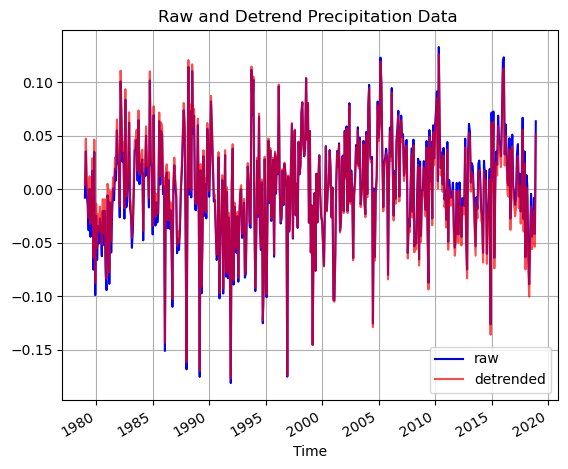

In [167]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds_prec.lat)).where(~prec_anom[0].isnull())
weights /= weights.mean()

(prec_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
(prec_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label = 'detrended')

plt.title("Raw and Detrend Precipitation Data ")
plt.grid()
plt.legend()

## load mslp data

In [168]:
ds_mslp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\mslp.mon.mean.nc")
ds_mslp = ds_mslp.sel(time = slice('1960', '2018')) 
ds_mslp.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 480, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 9.974e+04
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [169]:
#make anomaly
mslp_clim = ds_mslp.mslp.groupby('time.month').mean(dim = 'time')
mslp_anom = ds_mslp.mslp.groupby('time.month') - mslp_clim

In [170]:
from scipy.signal import detrend
mslp_anom_detrended = xr.apply_ufunc(detrend, mslp_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~mslp_anom.isnull())

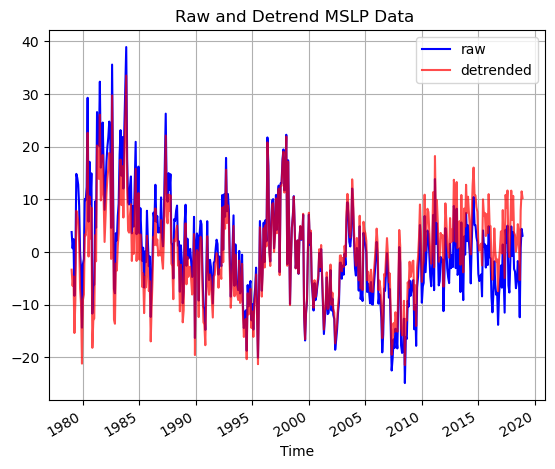

In [171]:
weights = np.cos(np.deg2rad(ds_mslp.lat)).where(~mslp_anom[0].isnull())
weights /= weights.mean()

(mslp_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
(mslp_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label = 'detrended')

plt.title("Raw and Detrend MSLP Data ")
plt.grid()
plt.legend()

# Calculate NINO 4 Index

In [172]:
ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
ds
# select period 選擇時間區間
ds = ds.sel(time = slice('1960', '2018')) 
#ds

#actually load the data
ds.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 708, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2018-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [173]:
#make anomaly
sst_clim = ds.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds.sst.groupby('time.month') - sst_clim

In [174]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [175]:
## nino 4

sst_anom_nino4 = sst_anom_detrended.sel(lat=slice(5, -5), lon = slice(160, 210)) #150w 160e
sst_anom_nino4_mean = sst_anom_nino4.mean(dim = ('lon', 'lat'))
oni4 = sst_anom_nino4_mean.rolling(time = 3, center=True).mean()  

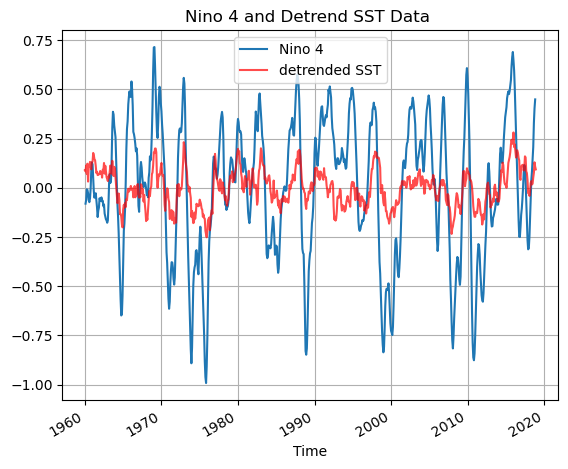

In [176]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds.lat)).where(~sst_anom[0].isnull())
weights /= weights.mean()

oni4_new = oni4/1.8
oni4_new.plot(label='Nino 4')
#(sst_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
(sst_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label='detrended SST')


plt.title("Nino 4 and Detrend SST Data ")
plt.grid()
plt.legend()

In [177]:
oni4_2 = oni4_new.sel(time = slice('1977', '2018')) 

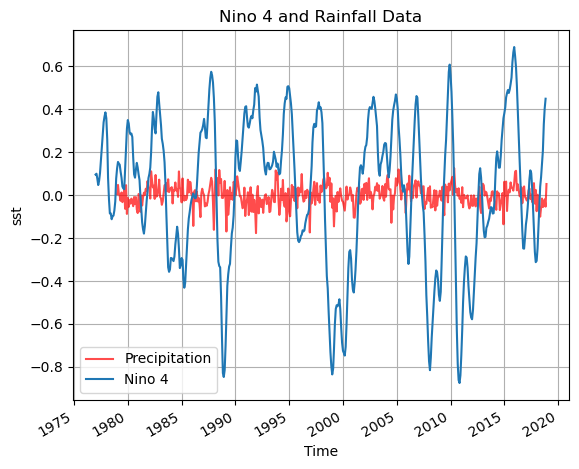

In [178]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds_prec.lat)).where(~prec_anom[0].isnull())
weights /= weights.mean()
#oni4_2_new = oni4/1.8
#(prec_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
a = (prec_anom_detrended * weights).mean(dim=['lon', 'lat'])
a.rolling(time = 3, center=True).mean()  
a.plot(alpha = 0.7,color = "red",label = 'Precipitation')
oni4_2.plot(label='Nino 4')

plt.title("Nino 4 and Rainfall Data")
plt.grid()
plt.legend()

In [179]:
mslp_anom_detrended_new = mslp_anom_detrended/34

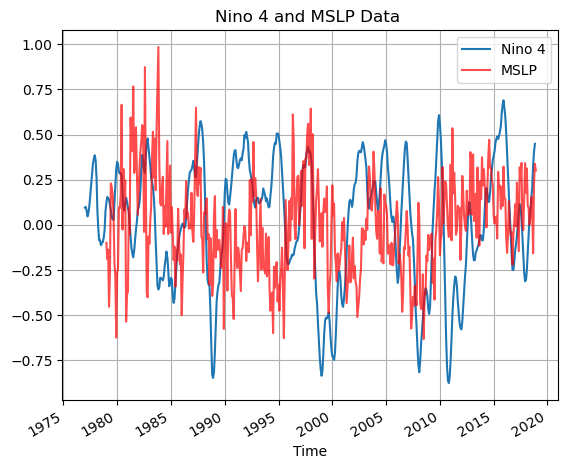

In [180]:
weights = np.cos(np.deg2rad(ds_mslp.lat)).where(~mslp_anom[0].isnull())
weights /= weights.mean()

oni4_2.plot(label='Nino 4')
#(mslp_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')

(mslp_anom_detrended_new * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label = 'MSLP')


plt.title("Nino 4 and MSLP Data ")
plt.grid()
plt.legend()

# Task3

In [186]:
## nino 3

sst_anom_nino3 = sst_anom_detrended.sel(lat=slice(5, -5), lon = slice(210, 270)) 
sst_anom_nino3_mean = sst_anom_nino3.mean(dim = ('lon', 'lat'))
oni3 = sst_anom_nino3_mean.rolling(time = 3, center=True).mean() 
oni3_111 = oni3/3.1 

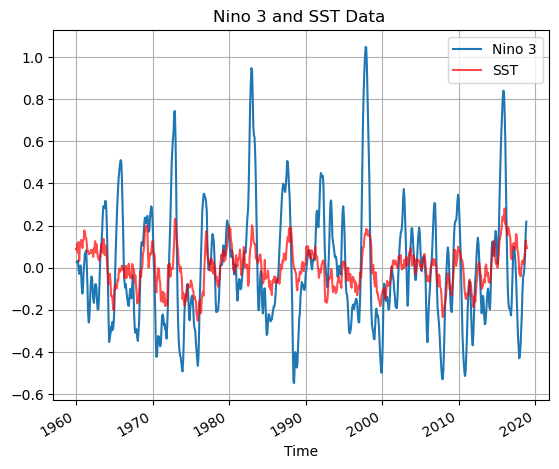

In [191]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds.lat)).where(~sst_anom[0].isnull())
weights /= weights.mean()

#oni3_new_2 = oni3/3.3
oni3_111.plot(label = 'Nino 3')
#(sst_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
(sst_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label='SST')


plt.title("Nino 3 and SST Data ")
plt.grid()
plt.legend()

In [124]:
oni3_2 = oni3.sel(time = slice('1977', '2018')) 

In [155]:
mslp_anom_detrended_new2 = mslp_anom_detrended/35
oni3_2_new = oni3_2/3.1

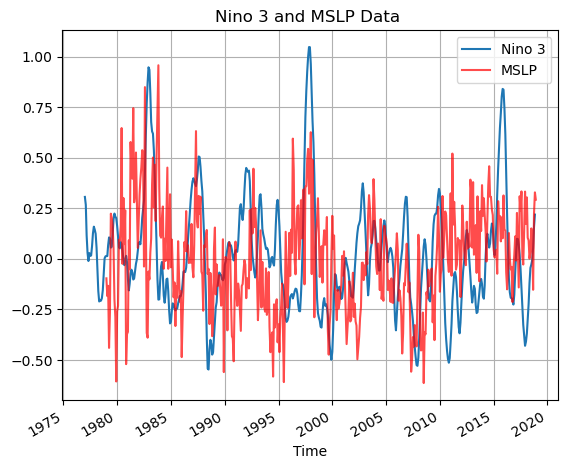

In [190]:
weights = np.cos(np.deg2rad(ds_mslp.lat)).where(~mslp_anom[0].isnull())
weights /= weights.mean()

oni3_2_new.plot(label='Nino 3')
#(mslp_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')

(mslp_anom_detrended_new2 * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label = 'MSLP')


plt.title("Nino 3 and MSLP Data ")
plt.grid()
plt.legend()